In [11]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import dcegm

jax.config.update("jax_enable_x64", True)

In [12]:
params = {}
params["interest_rate"] = 0.02
params["max_wealth"] = 50
params["wage_constant"] = 3
params["wage_exp_green"] = 0.5
params["wage_exp_red"] = 0.8
params["income_shock_std"] = 1
params["income_shock_mean"] = 0
params["taste_shock_scale"] = 1
params["discount_factor"] = 0.95
params["rho"] = 0.9
params["delta"] = 1.5
params["beta_green"] = 0.2
params["beta_red"] = 0.1

In [ ]:
model_specs = {
    "choices": [0, 1, 2],
}

In [ ]:
model_config = {
    "n_periods": 5,
    "choices": [0, 1, 2],
    "continuous_states": {
        "assets_end_of_period": jnp.linspace(0, 50, 100),
        "assets_begin_of_period": jnp.linspace(0, 50, 100),
    },
    "deterministic_states": {
        "exp_green": jnp.arange(0, 7, dtype=int),
        "exp_red": jnp.arange(0, 7, dtype=int),
    },
    "n_quad_points": 5,
    "upper_envelope": {"method": "druedahl_jorgensen"},
}

In [ ]:
model_config_cont_exp = {
    "n_periods": 5,
    "choices": [0, 1, 2],
    "continuous_states": {
        "assets_end_of_period": jnp.linspace(0, 50, 100),
        "assets_begin_of_period": jnp.linspace(0, 50, 100),
        "exp_green": jnp.arange(0, 7, dtype=float),
        "exp_red": jnp.arange(0, 7, dtype=float),
    },
    "n_quad_points": 5,
    "upper_envelope": {"method": "druedahl_jorgensen"},
}

In [14]:
# Utility functions
def flow_util(consumption, choice, params):
    rho = params["rho"]
    beta_green = params["beta_green"]
    beta_red = params["beta_red"]
    disutility = beta_red * (choice == 0) + beta_green * (choice == 1)
    u = consumption ** (1 - rho) / (1 - rho) - disutility
    return u


def marginal_utility(consumption, params):
    rho = params["rho"]
    u_prime = consumption ** (-rho)
    return u_prime


def inverse_marginal_utility(marginal_utility, params):
    rho = params["rho"]
    return marginal_utility ** (-1 / rho)


utility_functions = {
    "utility": flow_util,
    "inverse_marginal_utility": inverse_marginal_utility,
    "marginal_utility": marginal_utility,
}


def final_period_utility(wealth: float, choice: int, params):
    return flow_util(wealth, choice, params)


def marginal_final(wealth, choice, params):
    return marginal_utility(wealth, params)


utility_functions_final_period = {
    "utility": final_period_utility,
    "marginal_utility": marginal_final,
}

In [ ]:
def state_specific_choice_set(
    period,
    lagged_choice,
    model_specs,
):
    # Once the agent choses retirement, she can only choose retirement thereafter.
    # Hence, retirement is an absorbing state.
    if lagged_choice == 2:
        choice_set = [2]
    elif period == 4:
        choice_set = [2]
    else:
        choice_set = model_specs["choices"]

    return choice_set


def next_period_deterministic_state_cont(
    period,
    choice,
    lagged_choice,
):
    return {
        "period": period + 1,
        "lagged_choice": choice,
    }


def next_period_continuous_state(
    lagged_choice,
    period,
    exp_green,
    exp_red,
):
    return {
        "exp_red": exp_red + (lagged_choice == 0),
        "exp_green": exp_green + (lagged_choice == 1),
    }


state_space_functions_cont_exp = {
    "state_specific_choice_set": state_specific_choice_set,
    "next_period_deterministic_state": next_period_deterministic_state_cont,
    "next_period_continuous_state": next_period_continuous_state,
}


def next_period_deterministic_state(
    period,
    choice,
    lagged_choice,
    exp_green,
    exp_red,
):
    next_exp_green = exp_green + (lagged_choice == 1)
    next_exp_red = exp_red + (lagged_choice == 0)
    return {
        "period": period + 1,
        "exp_green": next_exp_green,
        "exp_red": next_exp_red,
        "lagged_choice": choice,
    }


def sparsity_condition(
    period,
    lagged_choice,
    exp_green,
    exp_red,
):
    if (exp_green + exp_red) > period:
        return False
    else:
        return True


state_space_functions_discrete_exp = {
    "state_specific_choice_set": state_specific_choice_set,
    "next_period_deterministic_state": next_period_deterministic_state,
    "sparsity_condition": sparsity_condition,
}


def budget_constraint_discrete_exp(
    lagged_choice,
    exp_green,
    exp_red,
    asset_end_of_previous_period,
    income_shock_previous_period,
    params,
):
    interest_factor = 1 + params["interest_rate"]
    wage = (
        params["wage_constant"]
        + params["wage_exp_green"] * exp_green * (lagged_choice == 1)
        + params["wage_exp_red"] * exp_red * (lagged_choice == 0)
    )
    resource = (
        interest_factor * asset_end_of_previous_period
        + (wage + income_shock_previous_period) * (lagged_choice != 2)
        + (wage + income_shock_previous_period) * 0.5 * (lagged_choice == 2)
    )
    return jnp.maximum(resource, 0.5)


def budget_constraint_cont_exp(
    period,
    lagged_choice,
    exp_green,
    exp_red,
    asset_end_of_previous_period,
    income_shock_previous_period,
    params,
):
    interest_factor = 1 + params["interest_rate"]
    wage = (
        params["wage_constant"]
        + params["wage_exp_green"] * exp_green * (lagged_choice == 1)
        + params["wage_exp_red"] * exp_red * (lagged_choice == 0)
    )
    resource = (
        interest_factor * asset_end_of_previous_period
        + (wage + income_shock_previous_period) * (lagged_choice != 2)
        + (wage + income_shock_previous_period) * 0.5 * (lagged_choice == 2)
    )
    return jnp.maximum(resource, 0.5)

In [3]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=utility_functions_final_period,
    state_space_functions=state_space_functions_discrete_exp,
    stochastic_states_transitions={},
    budget_constraint=budget_constraint_discrete_exp,
)

solved_model = model.solve(params)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  42
The batch size of the backwards induction is  41
The batch size of the backwards induction is  40
The batch size of the backwards induction is  39
The batch size of the backwards induction is  38
The batch size of the backwards induction is  37
The batch size of the backwards induction is  36
The batch size of the backwards induction is  35
The batch size of the backwards induction is  34
The batch size of the backwards induction is  33
The batch size of the backwards induction is  32
The batch size of the backwards induction is  31
The batch size of the backwards induction is  30
The batch size of the backwards induction is  29
The batch size of the backwards induction is  28
The batch size of the backwards induction is  27
The batch 

/opt/homebrew/Cellar/micromamba/2.5.0_2/envs/strenuousjobs/lib/python3.13/site-packages/dcegm/pre_processing/model_structure/state_choice_space.py:295: UserWarning: 



 Some states are not child states of any state-choice combination or stochastic transition. Please revisit the sparsity condition. 
 
An example of a state that is not a child state is: 
 
{'period': np.uint8(1), 'lagged_choice': np.uint8(0), 'exp_green': np.uint8(0), 'exp_red': np.uint8(0), 'dummy_stochastic': np.uint8(0)} 
 

  warnings.warn(


In [4]:
n_agents = 100
states_initial = {
    "n_agents": n_agents,
    "assets_begin_of_period": jnp.ones(n_agents),
    "exp_green": jnp.zeros(n_agents),
    "exp_red": jnp.zeros(n_agents),
    "lagged_choice": jnp.zeros(n_agents),
    "period": jnp.zeros(n_agents, dtype=int),
}

In [ ]:
simulate = model.get_solve_and_simulate_func(states_initial=states_initial, seed=99)
df = simulate(params)

In [7]:
model_cont_exp = dcegm.setup_model(
    model_config=model_config_cont_exp,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=utility_functions_final_period,
    state_space_functions=state_space_functions_cont_exp,
    stochastic_states_transitions={},
    budget_constraint=budget_constraint_cont_exp,
)

Sparsity condition not provided. Assume all states are valid.
Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  7
Model setup complete.



In [ ]:
# n_agents = 100
# states_initial = {
#     "n_agents": n_agents,
#     "assets_begin_of_period": jnp.ones(n_agents),
#     "exp_green": jnp.zeros(n_agents),
#     "exp_red": jnp.zeros(n_agents),
#     "lagged_choice": jnp.zeros(n_agents),
#     "period": jnp.zeros(n_agents, dtype=int),
# }

simulate_cont_exp = model_cont_exp.get_solve_and_simulate_func(
    states_initial=states_initial, seed=99
)

df_cont_exp = simulate_cont_exp(params)

<Axes: title={'center': 'Choice Probabilities - Continuous Experience Stocks'}, xlabel='period'>

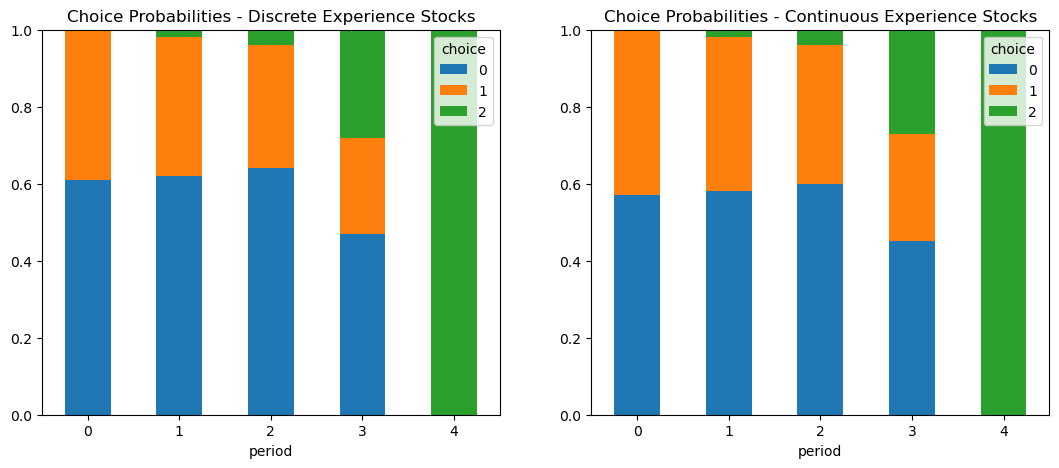

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
df.groupby("period").choice.value_counts(normalize=True).unstack().plot(
    stacked=True,
    kind="bar",
    rot=0,
    title="Choice Probabilities - Discrete Experience Stocks",
    ax=ax[0],
)

df_cont_exp.groupby("period").choice.value_counts(normalize=True).unstack().plot(
    stacked=True,
    kind="bar",
    rot=0,
    title="Choice Probabilities - Continuous Experience Stocks",
    ax=ax[1],
)

<Axes: title={'center': 'Choice Probabilities - Continuous Experience Stocks'}, xlabel='period'>

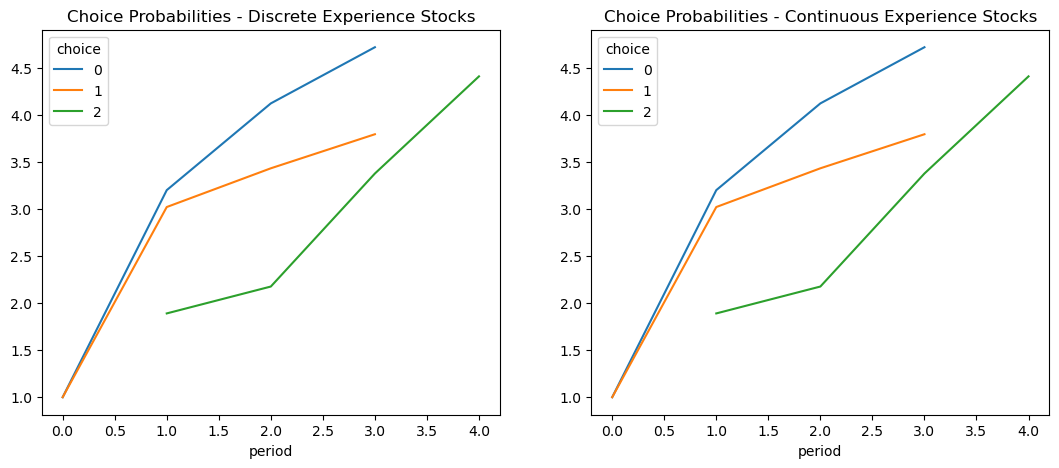

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
df.groupby(["period", "choice"]).consumption.mean().unstack().plot(
    rot=0, title="Choice Probabilities - Discrete Experience Stocks", ax=ax[0]
)

df.groupby(["period", "choice"]).consumption.mean().unstack().plot(
    rot=0, title="Choice Probabilities - Continuous Experience Stocks", ax=ax[1]
)